In [21]:
import math
def _gaussian_schedule(t, T, num_tasks, mu_exp=0.5, sigma=0.5, min_prob=0.2):
    '''
    Gaussian schedule for task sampling.
    mu_exp: exponent for the mean, typically 1.0. Move faster at the beginning: < 1.0. Move slower at the beginning: > 1.0
    sigma: standard deviation of the Gaussian distribution
    min_prob: minimum probability for each task
    '''
    # Move mean from 0 to (num_tasks-1) as time progresses, Use sqrt(t / T) to boost the the speed at the beginning
    mu = (t / T) ** mu_exp * (num_tasks - 1)

    if isinstance(min_prob, bool):
        p_min = 2 / (num_tasks * (num_tasks + 1)) if min_prob else 0.0
    elif isinstance(min_prob, float):
        p_min = min_prob
    else:
        raise ValueError("min_prob should be either a boolean or a float")

    # Calculate unnormalized probabilities using Gaussian PDF
    unnormalized_probs = {}
    for i in range(num_tasks):
        # Calculate PDF of Gaussian for task i
        exponent = -((i - mu) ** 2) / (2 * sigma ** 2)
        unnormalized_probs[i] = math.exp(exponent)
        unnormalized_probs[i] = max(unnormalized_probs[i], p_min)

    total = sum(unnormalized_probs.values())
    return {i: prob / total for i, prob in unnormalized_probs.items()}

def _cosine_schedule(t, T, num_tasks):
    total = num_tasks * (num_tasks + 1) / 2.0
    early = {i: (num_tasks - i) / total for i in range(num_tasks)}
    late = {i: (i + 1) / total for i in range(num_tasks)}
    alpha = 0.5 * (1 + math.cos(math.pi * t / T))
    probs = {i: alpha * early[i] + (1 - alpha) * late[i] for i in range(num_tasks)}
    # Enforce symmetric floor equal to the minimum probability in early/late.
    p_min = 2 / (num_tasks * (num_tasks + 1))
    for i in range(num_tasks):
        probs[i] = max(probs[i], p_min)
    norm = sum(probs.values())
    return {i: probs[i] / norm for i in probs}

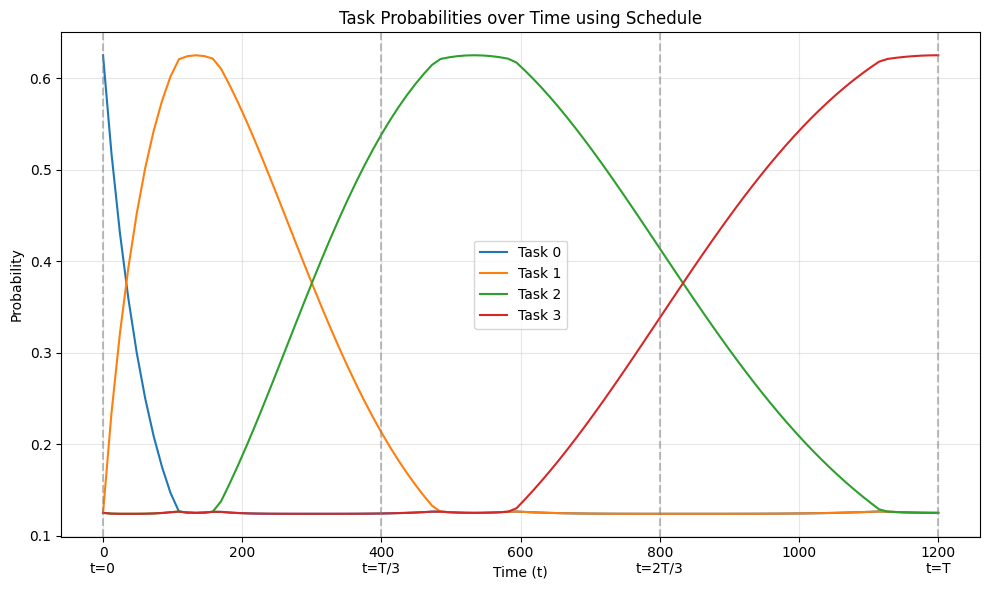

Probabilities at specific time points:
t=0: Task 0: 0.625  Task 1: 0.125  Task 2: 0.125  Task 3: 0.125  
t=T/3: Task 0: 0.124  Task 1: 0.213  Task 2: 0.538  Task 3: 0.124  
t=2T/3: Task 0: 0.124  Task 1: 0.124  Task 2: 0.414  Task 3: 0.338  
t=T: Task 0: 0.125  Task 1: 0.125  Task 2: 0.125  Task 3: 0.625  


In [22]:
def visualize_gaussian_schedule(T=1200, num_tasks=4, num_steps=100, scheduler=_gaussian_schedule):
    """
    Visualize how task probabilities change over time using the Gaussian schedule.
    
    Parameters:
    - T: Total time duration (default: 100)
    - num_tasks: Number of tasks (default: 4)
    - num_steps: Number of time points to plot (default: 100)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Generate time points
    time_points = np.linspace(0, T, num_steps)
    
    # Calculate probabilities for each task at each time point
    probabilities = []
    for i in range(num_tasks):
        task_probs = []
        for t in time_points:
            task_probs.append(scheduler(t, T, num_tasks)[i])
        probabilities.append(task_probs)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Line plot
    for i in range(num_tasks):
        plt.plot(time_points, probabilities[i], label=f'Task {i}')
    
    plt.title('Task Probabilities over Time using Schedule')
    plt.xlabel('Time (t)')
    plt.ylabel('Probability')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Add reference lines at key points
    special_points = [0, T/3, 2*T/3, T]
    special_labels = ['t=0', 't=T/3', 't=2T/3', 't=T']
    
    for point, label in zip(special_points, special_labels):
        plt.axvline(x=point, linestyle='--', color='gray', alpha=0.5)
        plt.text(point, -0.05, label, transform=plt.gca().get_xaxis_transform(), 
                ha='center', va='top')
    
    plt.tight_layout()
    plt.show()
    
    # Print the probabilities at key time points
    print("Probabilities at specific time points:")
    for point, label in zip(special_points, special_labels):
        probs = _gaussian_schedule(point, T, num_tasks)
        print(f"{label}:", end=" ")
        for i in range(num_tasks):
            print(f"Task {i}: {probs[i]:.3f}", end="  ")
        print()
visualize_gaussian_schedule()


In [ ]:
visualize_gaussian_schedule